# Elderly clustering and access to acute hospitals in Singapore

**Research question.** How does spatial clustering of elderly populations correlate with access to
healthcare services? By analysing geographical demographics, travel time by public transport, and
the financial limitations of the elderly, we assess whether existing health facilities are adequately
distributed and sufficiently accessible for an ageing society.

**Operationalisation**

| Concept | Definition | Measure in this notebook |
|---|---|---|
| Elderly | Singaporeans aged 65 and above | Residents aged 65+ per subzone (SingStat, June 2026). *Residents = citizens + PRs; the file does not split them.* |
| Healthcare services | Acute hospitals, public and private (MOH, 2026) | All 20 MOH acute hospitals (11 public incl. KK Women's and Children's and the Institute of Mental Health, 9 private), located with OpenStreetMap via oex. Polyclinics and GPs excluded. |
| Accessibility: travel time | Time from home to the nearest acute hospital (Blanco et al., 2025; Wong et al., 2022) | **Straight-line distance (km)** from where elderly live to the nearest acute hospital, as a proxy for travel time |
| Accessibility: public transport | Whether the elderly person can take public transport from home (Wong et al., 2022) | **Has PT access** if a bus stop or MRT/LRT station or entrance is within 400 m of home; each elderly resident is classified as with or without PT access |
| Financial limitation | | Share of residents living in HDB 1–2-room flats (Census 2020), the standard small-area low-income proxy |

**Inputs**

| Input | Source | Unit |
|---|---|---|
| Resident population by single year of age, June 2026 | SingStat (`census_2026_subzone_age_sex.csv`) | subzone |
| Subzone boundaries, URA Master Plan 2019 (no sea) | data.gov.sg | subzone |
| Residents by type of dwelling, Census 2020 | data.gov.sg | subzone |
| Acute hospitals, bus stops, MRT/LRT stations and entrances, residential buildings | OpenStreetMap via **oex** | point / polygon |
| MOH acute hospital list (name, sector, type, OSM id) | MOH (2026), `moh_acute_hospitals.csv` | hospital |

The OpenStreetMap layers come from `oex/configs/singapore_ageing.yaml`. To refresh them run
`oex-cli osm --config configs/singapore_ageing.yaml` inside the `oex` folder and copy
`output/sgp/osm/*.geojson` into `data/raw/oex/`.

**Outline**
1. Clean the census → elderly counts and shares per subzone
2. Map the elderly population
3. Spatial clustering of the elderly (global Moran's I, LISA)
4. Acute hospitals
5. Where the elderly live (population-weighted demand points)
6. Accessibility: public-transport access and distance to the nearest acute hospital
7. Financial limitation proxy
8. Does elderly clustering correlate with access?

In [1]:
# Requirements: pip install -r requirements.txt

import warnings
from pathlib import Path

import esda
import geopandas as gpd
import libpysal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotnine as p9
from scipy.spatial import cKDTree
from scipy.stats import kruskal, spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

RAW = Path("data/raw")
PROCESSED = Path("data/processed")
FIGURES = Path("output/figures")
TABLES = Path("output/tables")
for d in (PROCESSED, FIGURES, TABLES):
    d.mkdir(parents=True, exist_ok=True)

SVY21 = 3414  # Singapore's projected CRS, metres
SEED = 4002
np.random.seed(SEED)
ELDERLY_AGE = 65
MIN_POP = 1000  # subzones below this are non-residential (industrial, catchment, CBD) and make rates noisy

## 1. Clean the census

The SingStat file has a two-line title, then one row per planning area × subzone × age × sex, with
`Total` roll-up rows at every level and footnotes at the bottom. `-` means nil or negligible.
We keep subzone rows with `Sex == Total` and single-year ages, then sum ages 65+, 75+ and 85+.

In [ ]:
raw = pd.read_csv(RAW / "census_2026_subzone_age_sex.csv", skiprows=2, dtype=str) # ignore first 2 rows of spreadsheet
raw.columns = ["planning_area", "subzone", "age", "sex", "pop"]
raw = raw.dropna(subset=["age", "sex"])  # drops the blank and footnote rows

ages = raw[
    (raw.planning_area != "Total")
    & (raw.subzone != "Total")
    & (raw.age != "Total")
    & (raw.sex == "Total")
].copy()
ages["pop"] = pd.to_numeric(ages["pop"].str.replace(",", "").replace("-", "0"))
ages["age"] = ages["age"].str.replace(" & Over", "").astype(int)  # "90 & Over" -> 90

census = (
    ages.assign(
        pop65=lambda d: d["pop"].where(d.age >= ELDERLY_AGE, 0),
        pop75=lambda d: d["pop"].where(d.age >= 75, 0),
        pop85=lambda d: d["pop"].where(d.age >= 85, 0),
    )
    .groupby(["planning_area", "subzone"], as_index=False)[["pop", "pop65", "pop75", "pop85"]]
    .sum()
)
census["pct65"] = 100 * census.pop65 / census["pop"].replace(0, np.nan)
census["pct75"] = 100 * census.pop75 / census["pop"].replace(0, np.nan)

national = raw[(raw.planning_area == "Total") & (raw.age == "Total") & (raw.sex == "Total")]["pop"].iloc[0]
print(f"{len(census)} subzones in {census.planning_area.nunique()} planning areas")
print(f"Sum of subzones: {census['pop'].sum():,}  vs published total {national} (differences are rounding)")
print(f"Residents 65+: {census.pop65.sum():,} ({100 * census.pop65.sum() / census['pop'].sum():.1f}%)")
census.sort_values("pop65", ascending=False).head(10)

332 subzones in 55 planning areas
Sum of subzones: 4,239,130  vs published total 4,231,520 (differences are rounding)
Residents 65+: 827,220 (19.5%)


,planning_area,subzone,pop,pop65,pop75,pop85,pct65,pct75
276,Tampines,Tampines East,124840,28540,9530,2140,22.861262,7.633771
13,Bedok,Bedok North,79570,21100,8900,1920,26.517532,11.185120
278,Tampines,Tampines West,93210,17140,5530,1120,18.388585,5.932840
319,Woodlands,Woodlands East,97800,12740,3670,760,13.026585,3.752556
15,Bedok,Bedok South,47810,12510,5780,1570,26.166074,12.089521
129,Jurong West,Hong Kah,50620,12150,4650,940,24.002371,9.186092
135,Jurong West,Yunnan,64710,11960,3930,760,18.482460,6.073250
331,Yishun,Yishun West,50190,11750,4200,980,23.411038,8.368201
109,Hougang,Hougang West,42120,11120,3810,830,26.400760,9.045584
250,Sengkang,Rivervale,62090,10750,3350,630,17.313577,5.395394


## 2. Map the elderly population

Census subzone names match the URA Master Plan 2019 boundaries one-to-one (all 332), so we join on
planning area + subzone name. Subzones with fewer than `MIN_POP` residents are greyed out: their
percentages are unstable and they are not residential.

212 residential subzones hold 99.7% of residents 65+


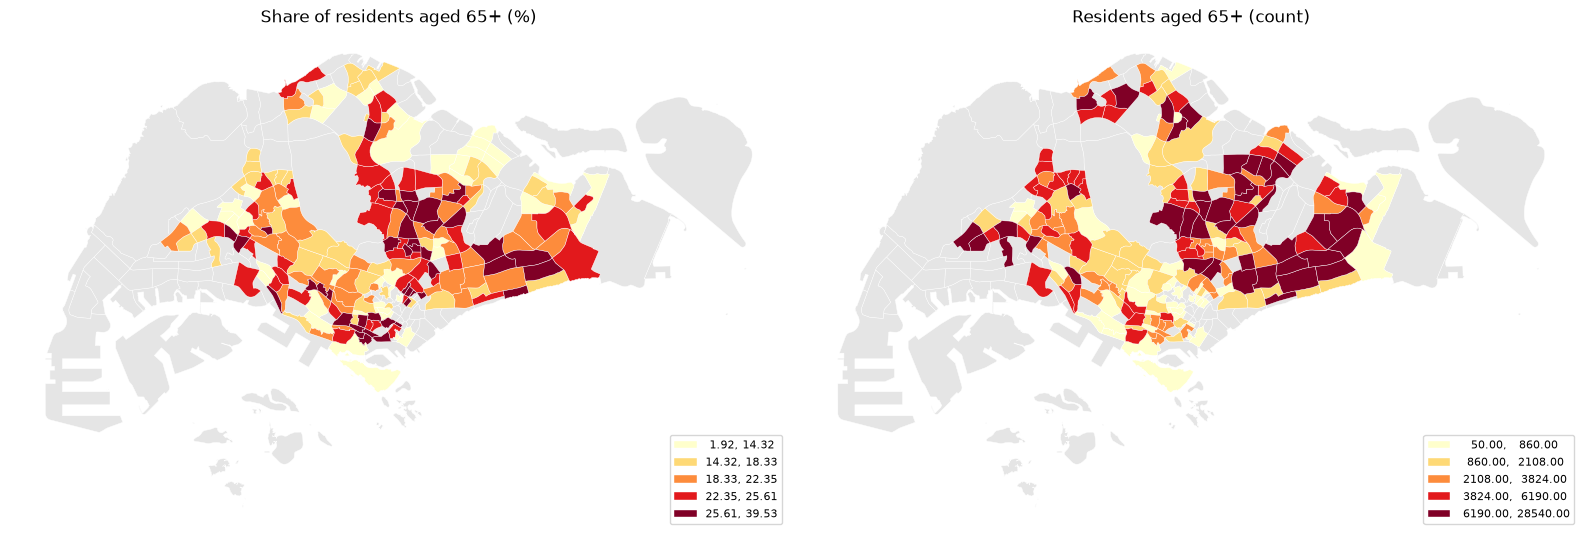

In [ ]:
subzones = gpd.read_file(RAW / "mp2019_subzone_no_sea.geojson").to_crs(SVY21) # read file and changes it into SVY21, coordinate system for sg
subzones["key"] = subzones.PLN_AREA_N.str.strip() + "|" + subzones.SUBZONE_N.str.strip()
census["key"] = census.planning_area.str.upper().str.strip() + "|" + census.subzone.str.upper().str.strip()

sz = subzones[["key", "SUBZONE_C", "REGION_N", "geometry"]].merge(census, on="key", how="left", validate="1:1")
assert sz["pop"].notna().all(), "every boundary should have a census row"
sz["area_km2"] = sz.area / 1e6
sz["residential"] = sz["pop"] >= MIN_POP # see above for what is the threshold for subzone to be residential. is this appropriate?
print(f"{sz.residential.sum()} residential subzones hold {sz.loc[sz.residential, 'pop65'].sum() / sz.pop65.sum():.1%} of residents 65+")

base = sz[~sz.residential]

# create a graph to show percentage of elderly in each subzone
def choropleth(ax, gdf, col, title, cmap="YlOrRd", k=5, bins=None):
    """Quantile classes by default; pass `bins` (upper bounds) for fixed classes."""
    scheme = {"scheme": "user_defined", "classification_kwds": {"bins": bins}} if bins else {"scheme": "quantiles", "k": k}
    base.plot(ax=ax, color="#e5e5e5", edgecolor="white", linewidth=0.3) # turns non-residential areas grey
    gdf.plot(ax=ax, column=col, cmap=cmap, legend=True, edgecolor="white", linewidth=0.3,
             legend_kwds={"loc": "lower right", "fontsize": 8}, **scheme)
    ax.set_title(title)
    ax.set_axis_off()

# create a second graph to plot number of elderly in each subzone
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
choropleth(axes[0], sz[sz.residential], "pct65", "Share of residents aged 65+ (%)")
choropleth(axes[1], sz[sz.residential], "pop65", "Residents aged 65+ (count)")
plt.tight_layout()
plt.savefig(FIGURES / "01_elderly_share_and_count.png", dpi=200)
plt.show()

## 3. Is the elderly population spatially clustered?

**Weights.** Dropping non-residential subzones leaves holes that break contiguity, so each subzone's
neighbours are its 6 nearest residential subzones (k-nearest neighbours, row-standardised).

**Global Moran's I** tests whether similar values sit next to each other across Singapore overall.
**Local Moran's I (LISA)** finds where: High-High = elderly hot spot, Low-Low = young cluster,
High-Low / Low-High = spatial outliers. Significance uses 999 conditional permutations at p < 0.05.

In [ ]:
res = sz[sz.residential].reset_index(drop=True).copy()
rep = res.representative_point()
w = libpysal.weights.KNN.from_array(np.column_stack([rep.x, rep.y]), k=6) # collate the coordinates of the 6 subzones surrounding each subzone
w.transform = "r"

moran_rows = []
for col, label in [("pct65", "Share 65+"), ("pct75", "Share 75+"), ("pop65", "Count 65+")]:
    mi = esda.Moran(res[col].values, w, permutations=999)
    moran_rows.append({"variable": label, "Moran's I": mi.I, "E[I]": mi.EI, "z": mi.z_sim, "p (perm)": mi.p_sim})
moran = pd.DataFrame(moran_rows).round(4)
moran.to_csv(TABLES / "global_moran.csv", index=False)
moran
# since moran's I is above 0 for all 3 variables, there is a slight positive correlation for clustering of elderly in some areas
# p-value is <0.05 for all 3 variables, suggesting there is evidence for spatial clustering of elderly

,variable,Moran's I,E[I],z,p (perm)
0,Share 65+,0.2120,-0.0047,5.6743,0.001
1,Share 75+,0.3536,-0.0047,9.6738,0.001
2,Count 65+,0.2717,-0.0047,7.4959,0.001


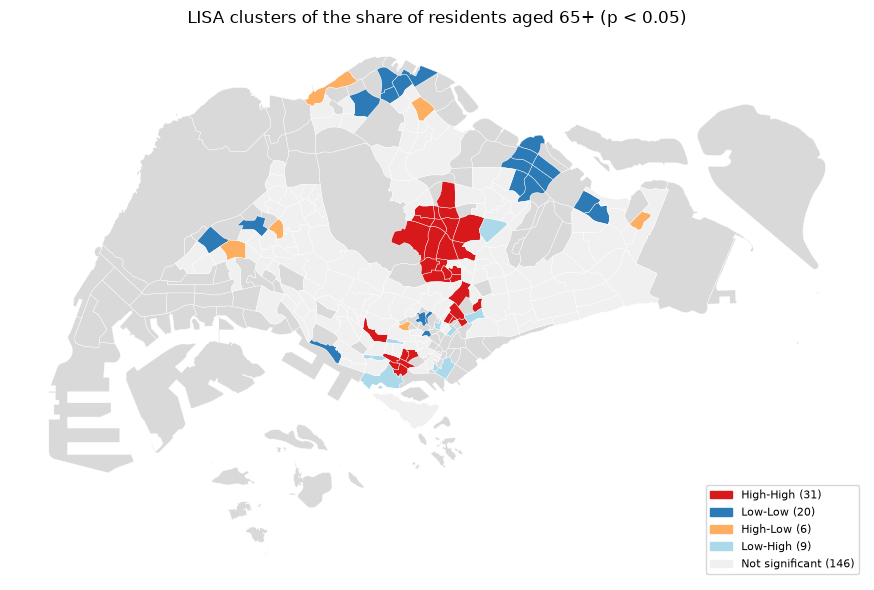

,planning_area,subzone,pop,pop65,pct65
187,Kallang,Crawford,7570,2840,37.516513
16,Bukit Merah,Telok Blangah Rise,11210,3760,33.541481
19,Bukit Merah,Telok Blangah Way,8090,2540,31.396786
44,Rochor,Little India,2940,920,31.292517
97,Ang Mo Kio,Chong Boon,24420,7550,30.917281
1,Bukit Merah,Bukit Merah,1050,320,30.476190
210,Ang Mo Kio,Townsville,19530,5770,29.544291
20,Bukit Merah,Kampong Tiong Bahru,9690,2800,28.895769
60,Toa Payoh,Pei Chun,9640,2740,28.423237
64,Ang Mo Kio,Kebun Bahru,21440,5960,27.798507


In [ ]:
LISA_COLOURS = {
    "High-High": "#d7191c", "Low-Low": "#2c7bb6", "High-Low": "#fdae61",
    "Low-High": "#abd9e9", "Not significant": "#f0f0f0",
}

# plot a map to show spatial clustering. red is those with high elderly %, and its neighbours all have high % too
def cluster_map(ax, gdf, col, colours, title):
    base.plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.3)
    for label, colour in colours.items():
        part = gdf[gdf[col] == label]
        if len(part):
            part.plot(ax=ax, color=colour, edgecolor="white", linewidth=0.3)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colours.values()]
    ax.legend(handles, [f"{k} ({(gdf[col] == k).sum()})" for k in colours], loc="lower right", fontsize=8)
    ax.set_title(title)
    ax.set_axis_off()


lisa = esda.Moran_Local(res["pct65"].values, w, permutations=999, seed=SEED)
quad = {1: "High-High", 2: "Low-High", 3: "Low-Low", 4: "High-Low"}
res["lisa_pct65"] = np.where(lisa.p_sim < 0.05, pd.Series(lisa.q).map(quad), "Not significant")

fig, ax = plt.subplots(figsize=(10, 6))
cluster_map(ax, res, "lisa_pct65", LISA_COLOURS, "LISA clusters of the share of residents aged 65+ (p < 0.05)")
plt.tight_layout()
plt.savefig(FIGURES / "02_lisa_elderly_share.png", dpi=200)
plt.show()

res.loc[res.lisa_pct65 == "High-High", ["planning_area", "subzone", "pop", "pop65", "pct65"]].sort_values(
    "pct65", ascending=False
)

## 4. Acute hospitals

OpenStreetMap tags about 130 features in Singapore as hospitals, most of them community hospitals,
testing centres or wards. The oex config (`Acute Hospitals` category) therefore pins the **20 MOH acute
hospitals** by OSM id: 11 public (9 acute general hospitals, KK Women's and Children's Hospital and the
Institute of Mental Health) and 9 private.

`data/raw/moh_acute_hospitals.csv` maps each OSM id to the MOH name, sector and type. Following our
definition, all 20 count as destinations. Two are single-specialty, KK Women's and Children's Hospital
and the Institute of Mental Health (mapped in OSM as the Buangkok Green Medical Park campus); add
their types to `EXCLUDED_TYPES` (e.g. `{"Women and children", "Psychiatric"}`) to test how much the
results depend on them.

In [6]:
EXCLUDED_TYPES = set()

moh = pd.read_csv(RAW / "moh_acute_hospitals.csv")
acute = gpd.read_file(RAW / "oex" / "oex_sgp_acute_hospitals_osm.geojson").to_crs(SVY21)
acute = acute[["id", "geometry"]].merge(moh, left_on="id", right_on="osm_id", how="outer", indicator=True)
assert (acute._merge == "both").all(), acute.loc[acute._merge != "both", ["id", "osm_id", "_merge"]]
acute = gpd.GeoDataFrame(acute.drop(columns=["_merge", "id"]).rename(columns={"hospital": "name"}), crs=SVY21)
acute["geometry"] = acute.representative_point()
print(f"oex export: {len(acute)} acute hospitals "
      f"({(acute.sector == 'Public').sum()} public, {(acute.sector == 'Private').sum()} private)")

hospitals = acute[~acute.hospital_type.isin(EXCLUDED_TYPES)].reset_index(drop=True)
print(f"Used as destinations: {len(hospitals)} (excluded types: {sorted(EXCLUDED_TYPES) or 'none'})")
acute.drop(columns="geometry").sort_values(["sector", "name"])

oex export: 20 acute hospitals (11 public, 9 private)
Used as destinations: 20 (excluded types: none)


,osm_id,name,sector,hospital_type
3,way/1345623876,Crawfurd Hospital,Private,Acute
0,node/6746490215,Farrer Park Hospital,Private,Acute
12,way/41890511,Gleneagles Hospital,Private,Acute
17,way/74715098,Mount Alvernia Hospital,Private,Acute (not-for-profit)
18,way/751064398,Mount Elizabeth Hospital,Private,Acute
6,way/260549167,Mount Elizabeth Novena Hospital,Private,Acute
10,way/397219610,Parkway East Hospital,Private,Acute
13,way/47134077,Raffles Hospital,Private,Acute
5,way/252835078,Thomson Medical Centre,Private,Acute
2,way/109104578,Alexandra Hospital,Public,Acute general


mode
Bus        5669
MRT/LRT     832


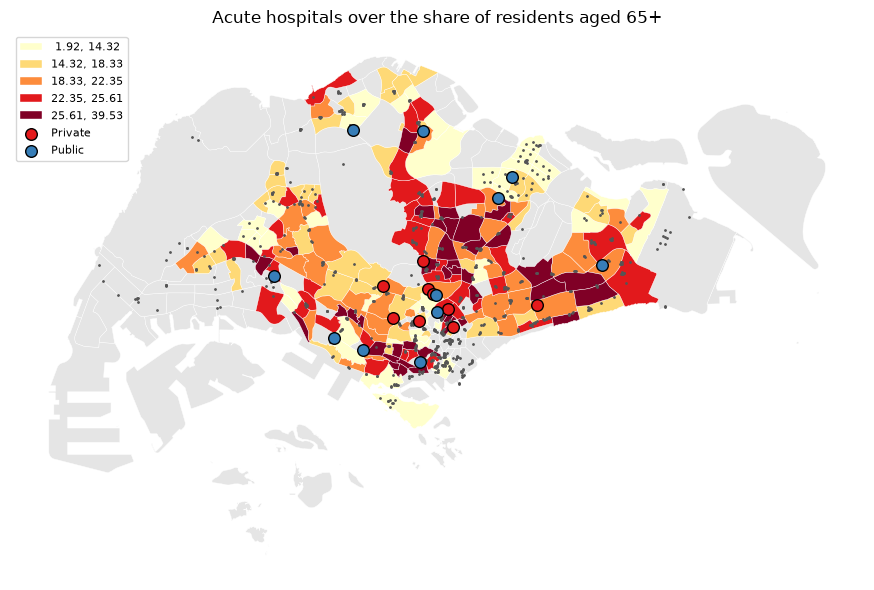

In [7]:
stops = gpd.read_file(RAW / "oex" / "oex_sgp_public_transport_stops_osm.geojson").to_crs(SVY21)
stops["geometry"] = stops.representative_point()
stops["mode"] = np.where(stops.highway == "bus_stop", "Bus", "MRT/LRT")
stops = stops[stops.railway != "construction"]  # the oex filter already kept only stops and stations
print(stops["mode"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 6))
choropleth(ax, res, "pct65", "Acute hospitals over the share of residents aged 65+")
stops[stops["mode"] == "MRT/LRT"].plot(ax=ax, color="#555555", markersize=1)
hospitals.plot(ax=ax, column="sector", categorical=True, cmap="Set1", markersize=70, edgecolor="black",
               legend=True, legend_kwds={"loc": "upper left", "fontsize": 8})
plt.tight_layout()
plt.savefig(FIGURES / "03_acute_hospitals.png", dpi=200)
plt.show()

## 5. Where do the elderly live?

Distance should be measured from *home*, not from a subzone centroid that may sit in a park or reservoir.
We spread each subzone's 65+ population over its residential buildings (from oex), weighted by
footprint area × storeys. Storeys default to 12 for blocks (`residential` / `apartments`, typical HDB)
and 2 for houses when OSM has no `building:levels`. Subzones with no mapped housing fall back to one
representative point. Each building then stands in for the elderly who live there.

In [8]:
bld = gpd.read_file(RAW / "oex" / "oex_sgp_residential_buildings_osm.geojson").to_crs(SVY21)
levels = pd.to_numeric(bld["levels"], errors="coerce")
default_levels = pd.Series(np.where(bld.building.isin(["residential", "apartments"]), 12, 2), index=bld.index)
bld["floor_area"] = bld.area * levels.fillna(default_levels).clip(1, 60)
bld["geometry"] = bld.representative_point()
bld = gpd.sjoin(bld[["floor_area", "geometry"]], sz[["key", "geometry"]], predicate="within").drop(columns="index_right")

# Elderly allocated to each building = subzone pop65 x building's share of the subzone's floor area.
bld["share"] = bld.floor_area / bld.groupby("key").floor_area.transform("sum")
bld = bld.merge(sz[["key", "pop65"]], on="key")
bld["pop65"] = bld.share * bld.pop65

missing = res[~res.key.isin(bld.key)]
fallback = gpd.GeoDataFrame({"key": missing.key, "pop65": missing.pop65, "share": 1.0},
                            geometry=missing.representative_point(), crs=SVY21)
homes = pd.concat([bld, fallback], ignore_index=True)
homes = gpd.GeoDataFrame(homes[homes.key.isin(res.key)].reset_index(drop=True), crs=SVY21)
print(f"{len(homes):,} home points for {homes.key.nunique()} residential subzones "
      f"({len(fallback)} subzones use a single fallback point)")

44,394 home points for 212 residential subzones (0 subzones use a single fallback point)


## 6. Accessibility

### 6a. Can the elderly person take public transport from home?

**Has PT access** = a bus stop or MRT/LRT station or entrance within `MAX_WALK_M` (400 m) of home.
400 m is LTA's walk-to-stop planning standard and roughly a 7-minute walk at an older adult's pace.
Every elderly resident allocated to a home point is classified as **with** or **without** PT access.
Try 300 m and 500 m to check sensitivity.

### 6b. How far is the nearest acute hospital?

We use the **straight-line (Euclidean) distance** from each home to the nearest acute hospital as a
proxy for travel time. It is simple and transparent, but it ignores the road and rail network, waiting
and transfers, so two homes the same distance away can have very different journeys.

Main measure: nearest of **any** of the 20 acute hospitals. Secondary measure: nearest **public**
acute hospital, since private hospitals cost far more, which links distance to the financial dimension.

In [9]:
MAX_WALK_M = 400


def xy(gdf):
    return np.column_stack([gdf.geometry.x, gdf.geometry.y])


P = xy(homes)
homes["walk_home_m"] = cKDTree(xy(stops)).query(P)[0]
homes["pt_access"] = homes.walk_home_m <= MAX_WALK_M

SCENARIOS = {"any": hospitals, "public": hospitals[hospitals.sector == "Public"].reset_index(drop=True)}
for scen, dest in SCENARIOS.items():
    dist, idx = cKDTree(xy(dest)).query(P)
    homes[f"hospital_{scen}"] = dest.name.values[idx]
    homes[f"dist_km_{scen}"] = dist / 1000

with_pt = homes.loc[homes.pt_access, "pop65"].sum()
without_pt = homes.loc[~homes.pt_access, "pop65"].sum()
print(f"Elderly with PT access (stop within {MAX_WALK_M} m): {with_pt:,.0f} ({with_pt / (with_pt + without_pt):.1%})")
print(f"Elderly without PT access: {without_pt:,.0f} ({without_pt / (with_pt + without_pt):.1%})")
weights = np.round(homes.pop65).astype(int)
for scen, dest in SCENARIOS.items():
    d = np.repeat(homes[f"dist_km_{scen}"], weights)
    print(f"Distance to nearest {scen} acute hospital ({len(dest)} sites), elderly-weighted: "
          f"median {np.median(d):.1f} km, 90th percentile {np.percentile(d, 90):.1f} km, max {d.max():.1f} km")

Elderly with PT access (stop within 400 m): 820,183 (99.4%)
Elderly without PT access: 4,927 (0.6%)
Distance to nearest any acute hospital (20 sites), elderly-weighted: median 2.0 km, 90th percentile 4.4 km, max 6.8 km
Distance to nearest public acute hospital (11 sites), elderly-weighted: median 2.4 km, 90th percentile 5.2 km, max 6.8 km


In [10]:
def weighted(g):
    w_ = g.pop65.clip(lower=1e-9)
    out = {
        "walk_home_m": np.average(g.walk_home_m, weights=w_),
        "pct_pt_access": 100 * np.average(g.pt_access, weights=w_),
        "pop65_no_pt": g.loc[~g.pt_access, "pop65"].sum(),
    }
    for scen in SCENARIOS:
        out[f"dist_km_{scen}"] = np.average(g[f"dist_km_{scen}"], weights=w_)
        out[f"nearest_{scen}"] = g.groupby(f"hospital_{scen}").pop65.sum().idxmax()
    return pd.Series(out)


access = homes.groupby("key").apply(weighted).reset_index()
res = res.merge(access, on="key", how="left")
res["extra_km_public"] = res.dist_km_public - res.dist_km_any
res[["dist_km_any", "dist_km_public", "extra_km_public", "pct_pt_access", "pop65_no_pt", "walk_home_m"]].describe().round(2)

,dist_km_any,dist_km_public,extra_km_public,pct_pt_access,pop65_no_pt,walk_home_m
count,212.00,212.00,212.00,212.00,212.00,212.00
mean,2.22,2.64,0.42,98.14,23.24,134.70
std,1.33,1.44,0.88,6.85,89.70,54.44
min,0.31,0.38,0.00,53.35,0.00,36.77
25%,1.20,1.48,0.00,100.00,0.00,105.12
50%,1.88,2.32,0.00,100.00,0.00,118.01
75%,3.06,3.71,0.41,100.00,0.00,145.31
max,6.26,6.26,4.44,100.00,756.88,428.52


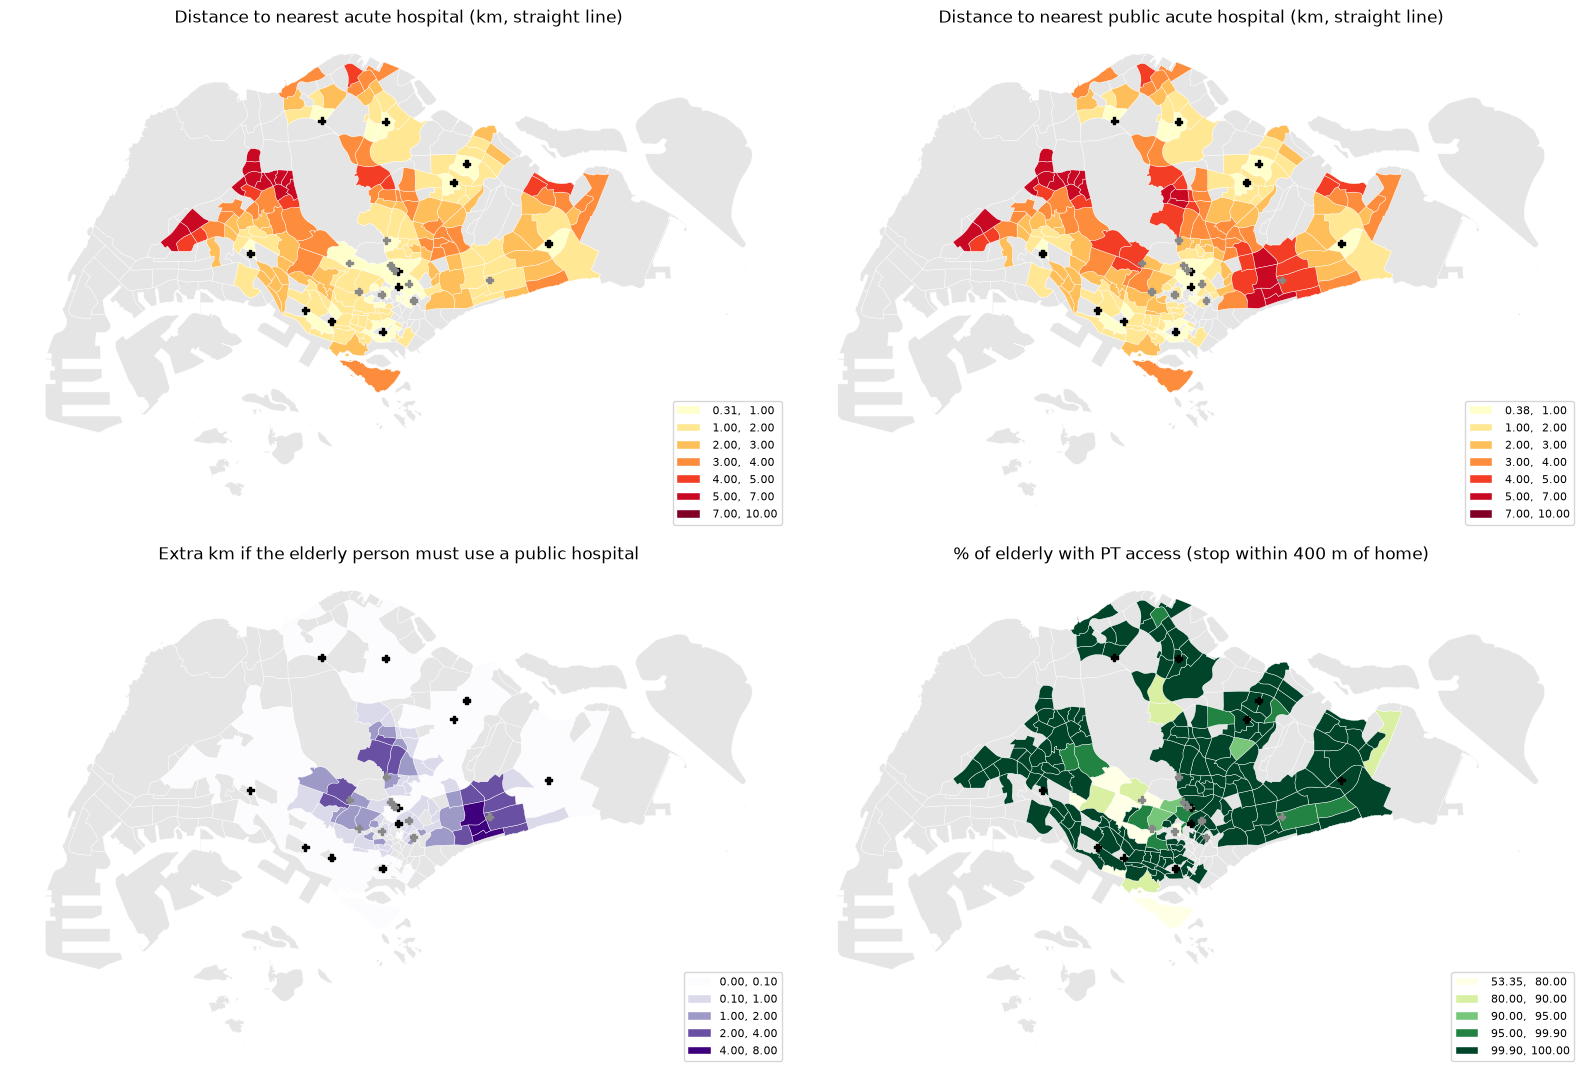

In [11]:
DIST_BINS = [1, 2, 3, 4, 5, 7, 10]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
choropleth(axes[0, 0], res, "dist_km_any", "Distance to nearest acute hospital (km, straight line)", bins=DIST_BINS)
choropleth(axes[0, 1], res, "dist_km_public", "Distance to nearest public acute hospital (km, straight line)", bins=DIST_BINS)
choropleth(axes[1, 0], res, "extra_km_public", "Extra km if the elderly person must use a public hospital",
           cmap="Purples", bins=[0.1, 1, 2, 4, 8])
choropleth(axes[1, 1], res, "pct_pt_access", f"% of elderly with PT access (stop within {MAX_WALK_M} m of home)",
           cmap="YlGn", bins=[80, 90, 95, 99.9, 100])
for ax in axes.flat:
    SCENARIOS["any"].plot(ax=ax, color=np.where(SCENARIOS["any"].sector == "Public", "black", "#888888"),
                          markersize=25, marker="P")
plt.tight_layout()
plt.savefig(FIGURES / "04_distance_and_pt_access.png", dpi=200)
plt.show()

## 7. Financial limitation proxy

Singapore does not publish elderly income by subzone. Census 2020 does publish residents by
**type of dwelling** per subzone, and the share living in **HDB 1–2-room flats** (largely public rental)
is the standard small-area proxy for low income. We also keep the 1–3-room share as a broader measure.
Census 2020 used the same MP2019 subzones. This is a 2020 snapshot of all ages, not elderly-specific.

In [12]:
dw = pd.read_csv(RAW / "census2020_subzone_dwelling.csv", dtype=str).rename(columns={"Number": "name"})
dw["is_pa"] = dw.name.str.endswith(" - Total")
dw["planning_area"] = dw.name.where(dw.is_pa).str.replace(" - Total", "").ffill()
dw = dw[~dw.is_pa & (dw.name != "Total")].copy()
num = ["Total", "HDBDwellings_1_and2_RoomFlats1", "HDBDwellings_3_RoomFlats"]
dw[num] = dw[num].replace("-", "0").apply(pd.to_numeric)
dw["key"] = dw.planning_area.str.upper().str.strip() + "|" + dw.name.str.upper().str.strip()
dw["pct_1_2room"] = 100 * dw.HDBDwellings_1_and2_RoomFlats1 / dw.Total.replace(0, np.nan)
dw["pct_1_3room"] = 100 * (dw.HDBDwellings_1_and2_RoomFlats1 + dw.HDBDwellings_3_RoomFlats) / dw.Total.replace(0, np.nan)
unmatched = sorted(set(res.key) - set(dw.key))
print(f"Matched {len(set(res.key) & set(dw.key))}/{len(res)} residential subzones; unmatched: {unmatched}")
res = res.merge(dw[["key", "pct_1_2room", "pct_1_3room"]], on="key", how="left")
res[["pct_1_2room", "pct_1_3room"]].describe().round(1)

Matched 211/212 residential subzones; unmatched: ['CHANGI|CHANGI WEST']


,pct_1_2room,pct_1_3room
count,207.0,207.0
mean,4.5,18.4
std,8.4,21.5
min,0.0,0.0
25%,0.0,0.0
50%,1.1,10.9
75%,5.4,29.5
max,70.6,96.0


## 8. Does elderly clustering correlate with access?

1. **Spearman correlations** between elderly / financial measures and access across subzones
   (rank-based, robust to skew; subzones are spatially dependent, so treat p-values as descriptive).
2. **Access by LISA cluster**: do elderly hot spots (High-High) live further from acute hospitals or
   have less PT access than elsewhere? (Kruskal-Wallis test.)
3. **Bivariate LISA** between the elderly share and distance to the nearest acute hospital: where do
   elderly hot spots sit among neighbourhoods far from hospital care?
4. **Priority subzones** combining need, access and financial limitation.

In [13]:
ACCESS = {
    "dist_km_any": "Km to nearest acute hospital",
    "dist_km_public": "Km to nearest public acute hospital",
    "extra_km_public": "Extra km to reach a public hospital",
    "pct_pt_access": "% elderly with PT access",
    "walk_home_m": "Walk from home to nearest stop (m)",
}
NEED = {"pct65": "Share 65+", "pop65": "Count 65+", "pct_1_2room": "% in 1-2-room HDB"}
rows = []
for x, xl in NEED.items():
    for y, yl in ACCESS.items():
        d = res[[x, y]].dropna()
        r, p = spearmanr(d[x], d[y])
        rows.append({"need": xl, "access": yl, "rho": round(r, 3), "p": float(f"{p:.3g}"), "n": len(d)})
corr = pd.DataFrame(rows)
corr.to_csv(TABLES / "spearman_need_vs_access.csv", index=False)
corr.pivot(index="access", columns="need", values="rho")

need,% in 1-2-room HDB,Count 65+,Share 65+
access,,,
% elderly with PT access,0.330,0.236,0.143
Extra km to reach a public hospital,-0.075,-0.125,0.210
Km to nearest acute hospital,-0.056,0.164,-0.139
Km to nearest public acute hospital,-0.111,0.145,-0.079
Walk from home to nearest stop (m),-0.302,-0.274,-0.120


In [14]:
corr

,need,access,rho,p,n
0,Share 65+,Km to nearest acute hospital,-0.139,0.043100,212
1,Share 65+,Km to nearest public acute hospital,-0.079,0.255000,212
2,Share 65+,Extra km to reach a public hospital,0.210,0.002120,212
3,Share 65+,% elderly with PT access,0.143,0.036900,212
4,Share 65+,Walk from home to nearest stop (m),-0.120,0.082000,212
5,Count 65+,Km to nearest acute hospital,0.164,0.017100,212
6,Count 65+,Km to nearest public acute hospital,0.145,0.035200,212
7,Count 65+,Extra km to reach a public hospital,-0.125,0.069400,212
8,Count 65+,% elderly with PT access,0.236,0.000528,212
9,Count 65+,Walk from home to nearest stop (m),-0.274,0.000052,212


In [15]:
by_cluster = res.groupby("lisa_pct65")[list(ACCESS)].median().round(1)
by_cluster["n subzones"] = res.lisa_pct65.value_counts()
pvals = {}
for col in ACCESS:
    groups = [g[col].dropna() for _, g in res.groupby("lisa_pct65") if len(g) >= 3]
    pvals[col] = float(f"{kruskal(*groups).pvalue:.3g}")
by_cluster.loc["Kruskal-Wallis p"] = pd.Series(pvals)
by_cluster.to_csv(TABLES / "access_by_lisa_cluster.csv")
by_cluster

,dist_km_any,dist_km_public,extra_km_public,pct_pt_access,walk_home_m,n subzones
lisa_pct65,,,,,,
High-High,1.700,2.100,0.400000,100.000,124.10,31.0
High-Low,3.200,3.200,0.000000,100.000,109.90,6.0
Low-High,1.700,2.000,0.000000,100.000,135.40,9.0
Low-Low,2.300,2.300,0.000000,100.000,109.40,20.0
Not significant,2.000,2.400,0.000000,100.000,118.30,146.0
Kruskal-Wallis p,0.261,0.506,0.000327,0.115,0.86,NaN


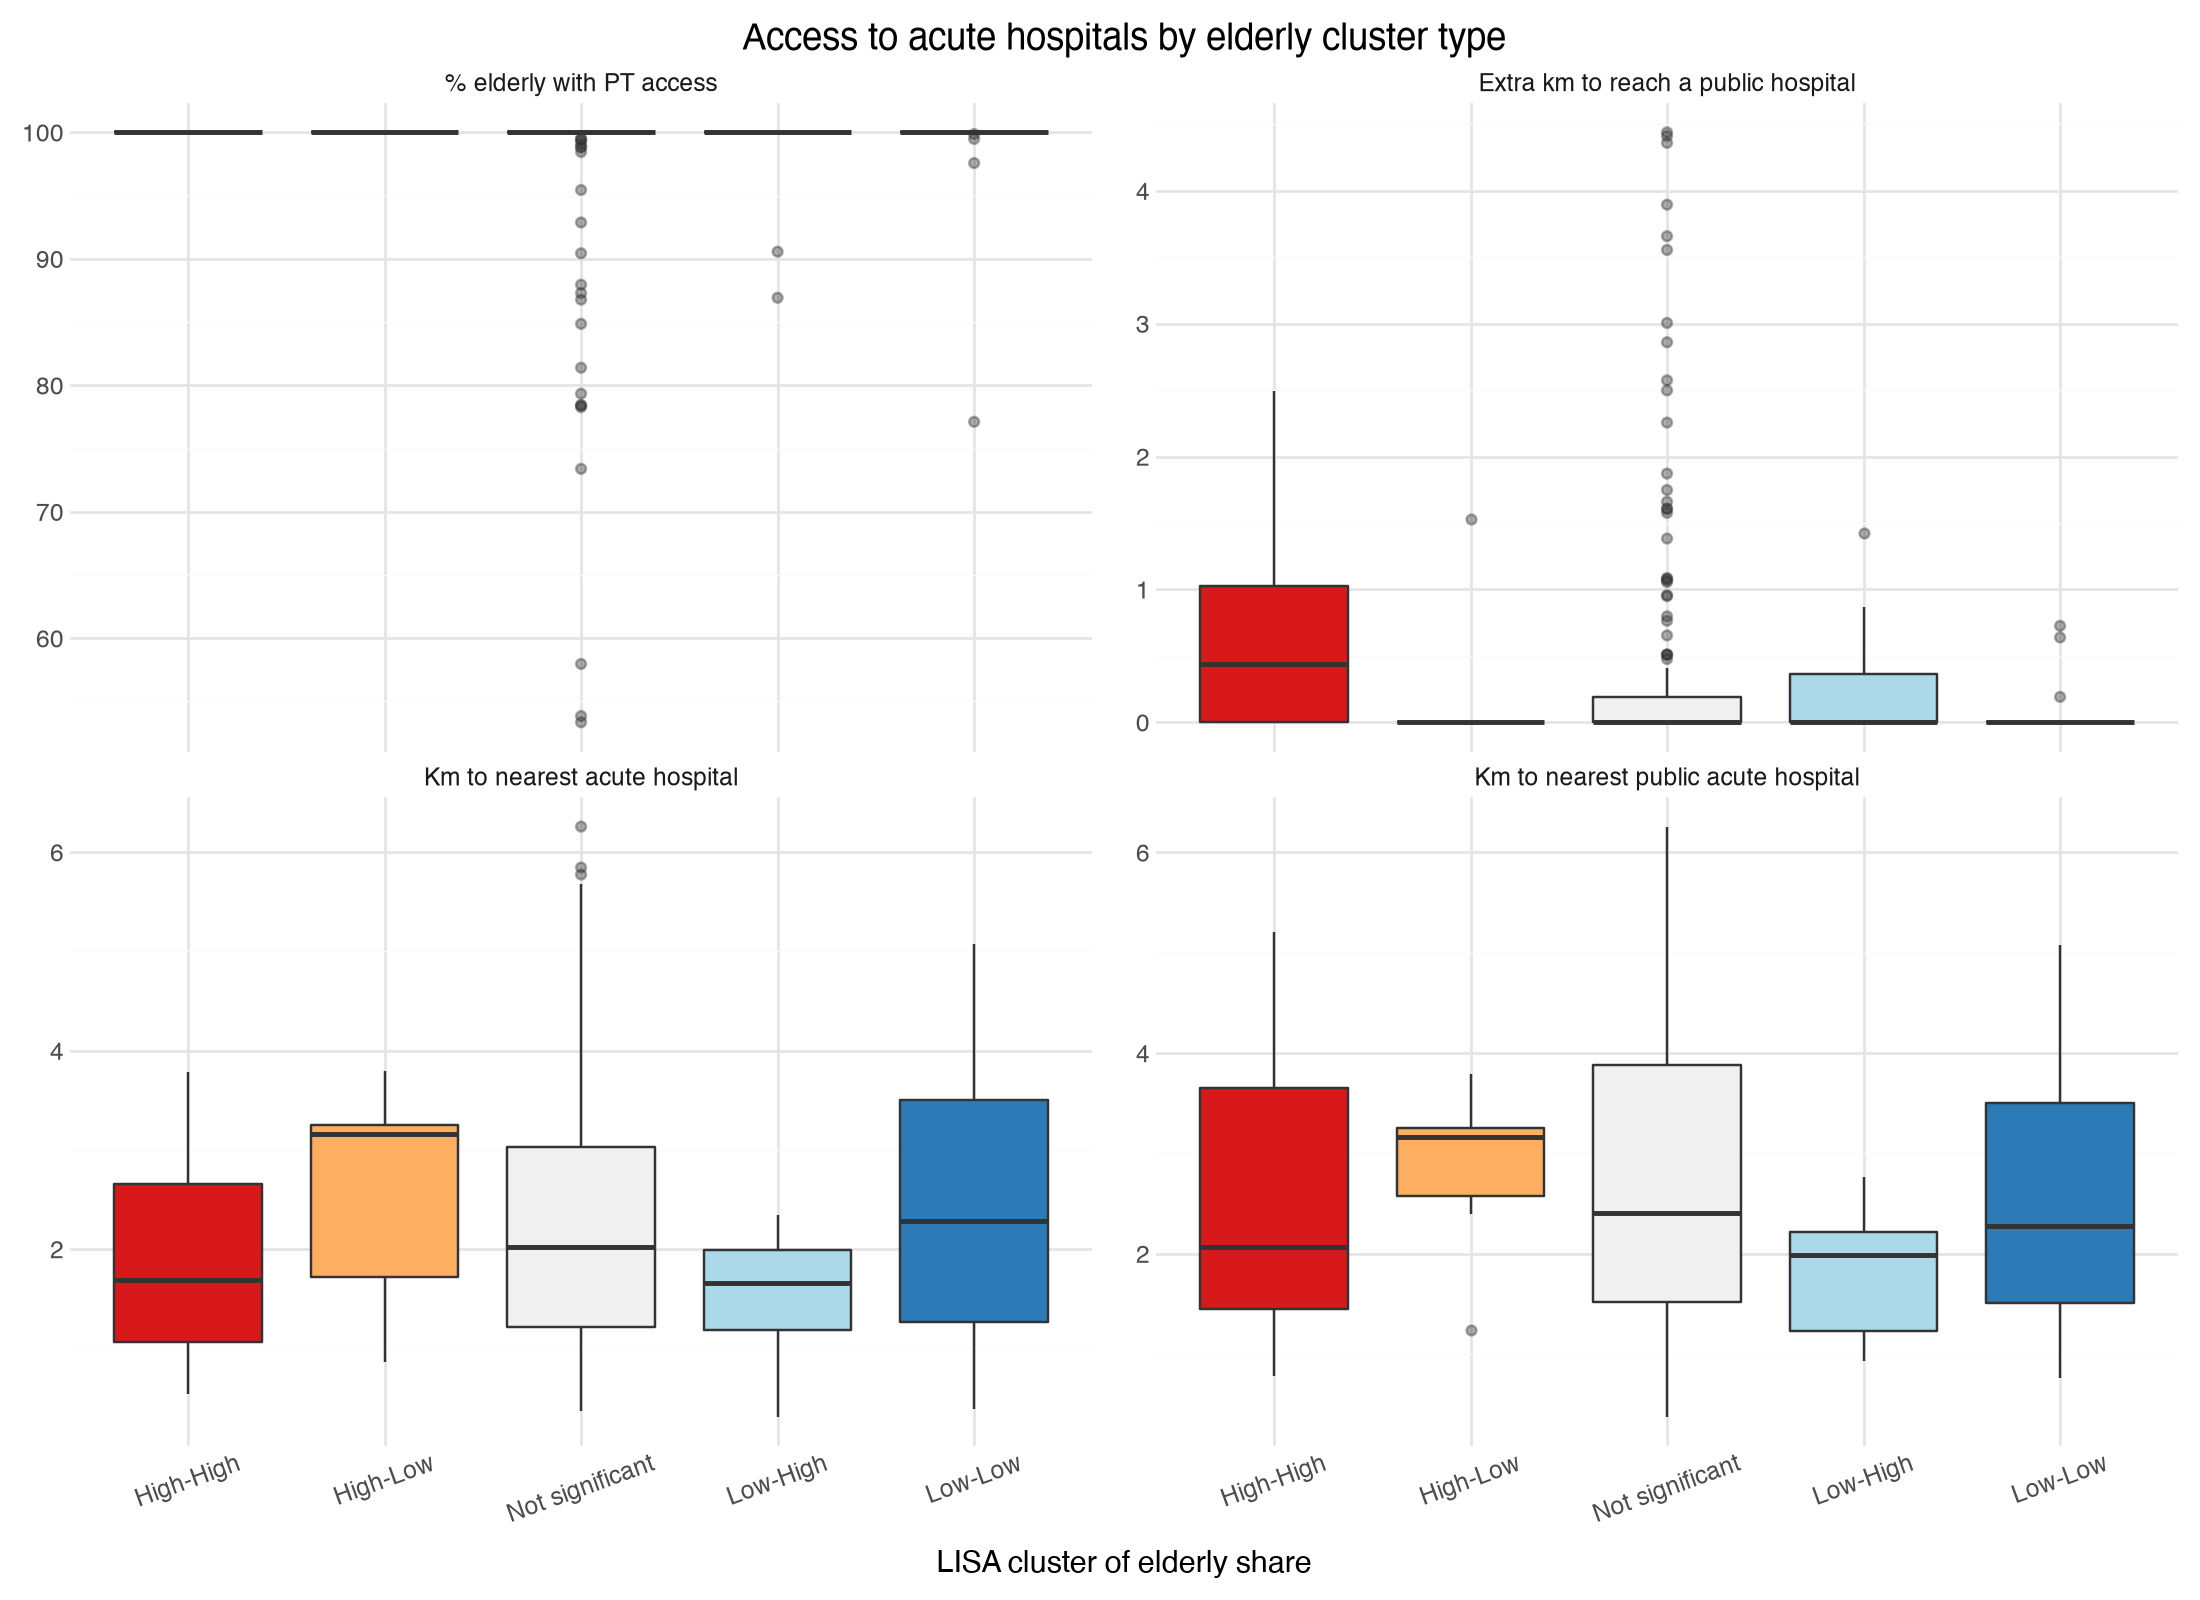

In [16]:
order = [o for o in ["High-High", "High-Low", "Not significant", "Low-High", "Low-Low"] if o in set(res.lisa_pct65)]
long = res.melt(id_vars="lisa_pct65", value_vars=["dist_km_any", "dist_km_public", "extra_km_public", "pct_pt_access"])
long["variable"] = long.variable.map(ACCESS)
long["lisa_pct65"] = pd.Categorical(long.lisa_pct65, categories=order)
(
    p9.ggplot(long, p9.aes("lisa_pct65", "value", fill="lisa_pct65"))
    + p9.geom_boxplot(outlier_alpha=0.4)
    + p9.facet_wrap("~variable", scales="free_y", ncol=2)
    + p9.scale_fill_manual(values=LISA_COLOURS)
    + p9.labs(x="LISA cluster of elderly share", y="", title="Access to acute hospitals by elderly cluster type")
    + p9.theme_minimal()
    + p9.theme(legend_position="none", figure_size=(11, 8), axis_text_x=p9.element_text(rotation=20))
)

Global bivariate Moran's I (elderly share vs neighbours' distance to hospital) = -0.096, p = 0.005


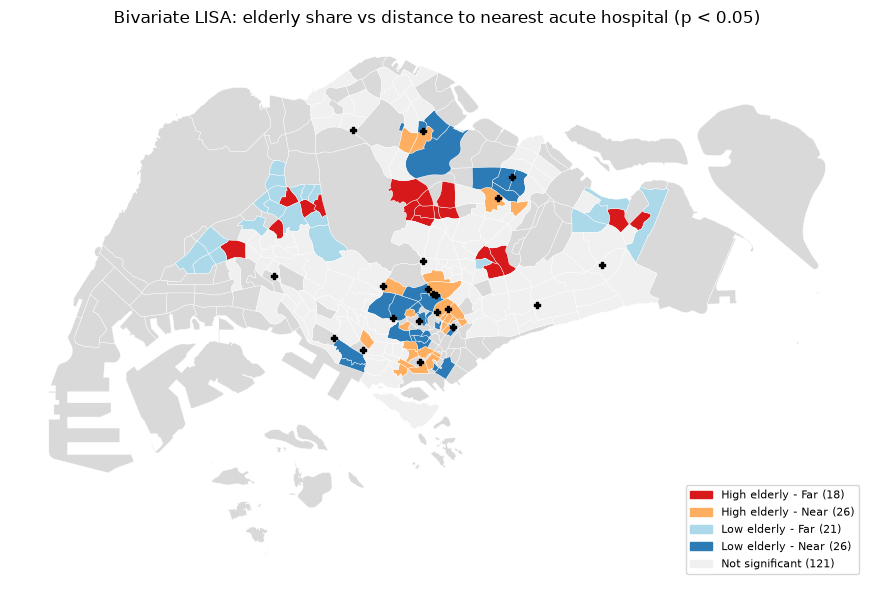

In [17]:
# Bivariate LISA: elderly share at i vs distance to hospital around i (spatial lag).
bv_global = esda.Moran_BV(res["pct65"].values, res["dist_km_any"].values, w, permutations=999)
print(f"Global bivariate Moran's I (elderly share vs neighbours' distance to hospital) = {bv_global.I:.3f}, p = {bv_global.p_sim:.3f}")
bv = esda.Moran_Local_BV(res["pct65"].values, res["dist_km_any"].values, w, permutations=999, seed=SEED)
bv_quad = {1: "High elderly - Far", 2: "Low elderly - Far", 3: "Low elderly - Near", 4: "High elderly - Near"}
res["bv_cluster"] = np.where(bv.p_sim < 0.05, pd.Series(bv.q).map(bv_quad), "Not significant")
BV_COLOURS = {"High elderly - Far": "#d7191c", "High elderly - Near": "#fdae61",
              "Low elderly - Far": "#abd9e9", "Low elderly - Near": "#2c7bb6",
              "Not significant": "#f0f0f0"}
fig, ax = plt.subplots(figsize=(10, 6))
cluster_map(ax, res, "bv_cluster", BV_COLOURS, "Bivariate LISA: elderly share vs distance to nearest acute hospital (p < 0.05)")
SCENARIOS["any"].plot(ax=ax, color="black", markersize=25, marker="P")
plt.tight_layout()
plt.savefig(FIGURES / "05_bivariate_lisa_elderly_vs_distance.png", dpi=200)
plt.show()

### Priority subzones

A subzone is flagged when it has **high elderly need** (top quartile of share 65+ *or* of residents
65+) **and** an **access gap** (top-quartile distance to the nearest acute hospital *or* fewer than 80%
of elderly with PT access). The financial flag marks top-quartile 1–2-room HDB share. Thresholds are
judgement calls: change them and check the list is stable.

In [18]:
res["high_need"] = (res.pct65 >= res.pct65.quantile(0.75)) | (res.pop65 >= res.pop65.quantile(0.75))
res["far_from_hospital"] = res.dist_km_any >= res.dist_km_any.quantile(0.75)
res["low_pt_access"] = res.pct_pt_access < 80
res["low_income"] = res.pct_1_2room >= res.pct_1_2room.quantile(0.75)
priority = res[res.high_need & (res.far_from_hospital | res.low_pt_access)].sort_values(
    ["low_income", "dist_km_any"], ascending=False)
show = ["planning_area", "subzone", "pop65", "pct65", "lisa_pct65", "nearest_any", "dist_km_any",
        "nearest_public", "dist_km_public", "pct_pt_access", "pop65_no_pt", "pct_1_2room",
        "far_from_hospital", "low_pt_access", "low_income"]
priority[show].round(1).to_csv(TABLES / "priority_subzones.csv", index=False)
print(f"{len(priority)} priority subzones with {priority.pop65.sum():,.0f} residents 65+ "
      f"({priority.pop65.sum() / res.pop65.sum():.1%} of elderly in residential subzones); "
      f"{priority.low_income.sum()} also have a low-income flag")
priority[show].round(1)

17 priority subzones with 114,990 residents 65+ (13.9% of elderly in residential subzones); 4 also have a low-income flag


,planning_area,subzone,pop65,pct65,lisa_pct65,nearest_any,dist_km_any,nearest_public,dist_km_public,pct_pt_access,pop65_no_pt,pct_1_2room,far_from_hospital,low_pt_access,low_income
165,Choa Chu Kang,Teck Whye,5550,23.1,Not significant,Ng Teng Fong General Hospital,5.2,Ng Teng Fong General Hospital,5.2,100.0,0.0,7.2,True,False,True
158,Ang Mo Kio,Yio Chu Kang West,6030,24.9,Not significant,Mount Alvernia Hospital,4.2,Khoo Teck Puat Hospital,4.7,100.0,0.0,11.0,True,False,True
64,Ang Mo Kio,Kebun Bahru,5960,27.8,High-High,Mount Alvernia Hospital,3.4,Institute of Mental Health,5.2,100.0,0.0,7.0,True,False,True
97,Ang Mo Kio,Chong Boon,7550,30.9,High-High,Mount Alvernia Hospital,3.2,Institute of Mental Health,3.7,100.0,0.0,5.5,True,False,True
177,Jurong West,Yunnan,11960,18.5,Not significant,Ng Teng Fong General Hospital,5.8,Ng Teng Fong General Hospital,5.8,100.0,0.0,2.3,True,False,False
163,Choa Chu Kang,Yew Tee,6070,15.7,Not significant,Woodlands Hospital,5.8,Woodlands Hospital,5.8,100.0,0.0,0.0,True,False,False
155,Bukit Panjang,Bangkit,5140,25.1,Not significant,Woodlands Hospital,5.5,Woodlands Hospital,5.5,100.0,0.0,0.0,True,False,False
106,Bukit Panjang,Jelebu,6500,22.3,Not significant,Ng Teng Fong General Hospital,5.3,Ng Teng Fong General Hospital,5.3,100.0,0.0,0.0,True,False,False
156,Choa Chu Kang,Peng Siang,5700,17.4,Not significant,Ng Teng Fong General Hospital,5.1,Ng Teng Fong General Hospital,5.1,100.0,0.0,1.2,True,False,False
142,Jurong West,Jurong West Central,9510,15.8,Not significant,Ng Teng Fong General Hospital,5.0,Ng Teng Fong General Hospital,5.0,100.0,0.0,0.1,True,False,False


In [19]:
res.drop(columns="geometry").to_csv(PROCESSED / "subzone_elderly_access.csv", index=False)
res.to_file(PROCESSED / "subzone_elderly_access.gpkg", driver="GPKG")
homes.to_file(PROCESSED / "elderly_home_points.gpkg", driver="GPKG")
print("Saved data/processed/subzone_elderly_access.{csv,gpkg} and elderly_home_points.gpkg")

Saved data/processed/subzone_elderly_access.{csv,gpkg} and elderly_home_points.gpkg


## Limitations

* **Elderly = residents 65+.** SingStat's subzone file covers citizens and PRs together; it cannot
  isolate Singaporeans.
* **Travel time is proxied by straight-line distance.** It ignores the road and rail network, waiting,
  transfers and walking speed, so it understates journeys across water, expressways or estates with
  poor connections. Network-based public-transport routing (e.g. OneMap or a GTFS router) would turn
  distance into minutes.
* **PT access only checks the home end.** A stop within 400 m of home does not guarantee a convenient
  route to the hospital; every acute hospital here has a stop nearby, but transfers are not counted.
* **"Nearest" hospital** is the straight-line nearest. In practice elderly may be tied to the public
  hospital of their regional health cluster, and KK Women's and Children's Hospital and the Institute
  of Mental Health serve only some needs; see `EXCLUDED_TYPES` in section 4 for a sensitivity check.
* **Homes** are OSM residential buildings; OSM completeness varies, though HDB estates are well mapped.
* **Financial proxy** is all-age, 2020 and dwelling-based. Pioneer/Merdeka Generation counts or
  elderly in HDB rental flats would be more direct.
* **MAUP.** Results depend on subzone boundaries; repeat at planning-area level or with different `k`
  to check robustness.